# Generating Neutral Redistricting Maps for Utah

Welcome! This project is designed to empower you to explore fair and neutral possibilities for Utah's electoral districts. We will be using a method called ensemble analysis to generate thousands of potential district maps that all follow a consistent set of neutral rules based on Utah's Proposition 4.

In this notebook, we will develop a set of rules and instructions to guide the computer in drawing maps, drawing a sample of maps and confirming the algorithm is satisfying the neutral standards to your liking. Then we'll import your configuration into the large scale environment for full ensemble analysis of Utah's redistricting requirements, including its prohibition on partisan gerrymandering.

## What Is an Ensemble and Why Is It Useful?

It's impossible to find the single "best" or "fairest" map. Instead, we can generate a large collection of maps called an __ensemble__ that all comply with a given set of legal and community-based criteria.

Think of it like this: if you ask 10,000 different people to draw a "fair" map, you could get up to 10,000 different valid maps. Some of them might be quite unique, while others could even be identical, but together they represent a general distribution of what fair maps look like. By studying this entire collection, we can understand the _range_ of possible outcomes. If an officially proposed or enacted map looks very different from the vast majority of maps in our neutral ensemble, it might be an outlier worth scrutinizing.

To create this ensemble, we will use a technique called a __Markov Chain Monte Carlo (MCMC)__ simulation. Specifically, we use a method called __Recombination (ReCom)__, which is designed to explore a wide variety of map configurations efficiently. In simple terms, our program will:
1. Start with an existing map.
2. Randomly pick two neighboring districts.
3. Temporarily merge them into one large "super-district".
4. Randomly draw a new boundary within this super-district to split it back into two new, population-balanced districts.
5. Check if this newly-drawn map follows all of our other rules.
6. If it does, we add it to our collection and repeat.

By doing this thousands of times, we build a massive, diverse ensemble of valid district maps.

## Basic Settings
You can also choose a "seed" for the random number generator, so your exact ensemble can be reproduced later.

Choose how many maps this configuration tuning notebook will generate and how many should be rendered for visualization. Note that when you import your chosen parameters into the full ensemble runner, you will be able to set the ensemble size and render frequency there.

In [1]:
import utgc.notebookhelper as nbh

# Initialization parameters
init_params = {
    # Seed for the random number generator
    "random_seed": 1847,
    # Path to a shapefile that will be used to initialize the algorithm
    # This also sets the number of districts the map will have
    "initial_partition": "plans/CONG/2025_UT-C/2025_UT-C.shp",  # Congress
    # "initial_partition": "plans/SLDL/ut_sldl_2021/ut_sldl_2021.shp", # State house
    # "initial_partition": "plans/SLDU/ut_sldu_2021/ut_sldu_2021.shp", # State senate
    # Path to a shapefile with the geography to be partitioned
    "nodes_data": "data/UT_precincts.geojson",
}
# Ensemble parameters
ensemble_params = {
    "steps": 51,  # Number of maps to generate
    "visualize_every": 1,  # Number of maps between renders
}

num_districts = nbh.get_district_count(init_params["initial_partition"])
print(f"Number of districts: {num_districts}")

Number of districts: 4


## Utah's Neutral Redistricting Standards

Utah law provides the following standards for how maps must be drawn, which are given an order of priority.
1. Follow the US. Constitution and federal law, maintaining equal population in districts and complying with the Voting Rights Act.
2. Minimize splitting cities and counties, with cities being most important to keep whole.
3. Make districts geographically compact.
4. Make districts contiguous and allow ease of travel throughout district
5. Preserve neighborhoods and communities of interest
6. Where possible, follow mountains, rivers, and other natural boundaries.
7. Where possible, line up the boundaries of different types of districts (e.g., Congressional and State Senate)

We have a variety of tools at our disposal to help the computer follow these rules, but how _exactly_ to balance the different priorities is a question for humans to answer.

## Select Parameters
In the sections below, you can configure different parameters to match your interpretation of the law's priorities. There's no harm in experimenting, so give it a go!

In [2]:
# Configuration files and example maps will be saved to a directory with the current date and time plus an optional user-defined tag
config_tag = ""  # <-- Change this to something descriptive if desired

### Constraints
One way to guide map drawing is through __constraints__. When a constraint is not met, the map is rejected and the algorithm must draw new maps until it creates one that passes. 

In [ ]:
# Constraints configuration
constraint_params = {
    # How much can a district's population deviate from the ideal population?
    "pop_deviation": 0.001,  # 0.001 is equivalent to 0.1%
    # How many municipalities can be split total?
    "split_munis_constraint": num_districts + 1,
    # How many splits past the first for each muni are allowed (map wide)?
    "muni_multi_splits_constraint": 0,
    # How many counties can be split total?
    "split_counties_constraint": num_districts + 1,
    # How many splits past the first for each county are allowed (map wide)?
    "county_multi_splits_constraint": round(num_districts / 3),
    # Whether to prevent the algorithm from drawing the same map twice in a row
    "include_not_equal_constraint": True,
}

### Region Surcharges
A __region surcharge__ adjusts the probability that the algorithm will draw a line that cuts through a region of that type, with _higher_ values making it _less_ likely to be split. Using all zeros would allow the algorithm to draw lines with uniform probablity--leaving it very free to explore, but potentially very bad at meeting constraints or honoring that particular criterion. On the other hand, large values help encourage keeping that region type intact (and meeting any related constraints). If a surcharge is too large, however, it can dramatically limit the space of maps that are possible to explore, and the algorithm might draw the same map many times. 

In [4]:
# Region surcharge configuration
region_surcharge_params = {
    "muni": 2,  # municipalities
    "county": 0.5,  # counties
    "highered": 0.3,  # institutions of higher education
    "metro": 0.3,  # metro/micropolitan areas
    "school_district": 0.1,  # school districts
    "water_region": 0.1,  # water planning regions
    "basin": 0.1,  # hydrologic basins
}

### Pruning and Weighting
Optionally, you choose to increase the penalty of crossing borders that that are difficult to traverse in real life, or remove them entirely from the computation graph. These options help ensure that districts are connected by actual roads and not separated by impassable barriers like major water bodies.

In [5]:
 # Path to precomputed transitability graph
transitability_graph = "data/transitability/_border_repaired/transitability.json"

### Tilted Run
The last way to influence the map drawing process is through a __tilted run__. During a tilted run, the algorithm scores each map on some criterion. If a map scores better than the one before it, the map is accepted. If the map scores worse, there is some probability that the map will be rejected. This encourages the ensemble generally to sample maps that perform well on that score, without enforcing it strictly. Here, we will use it to encourage compact districts.

In [6]:
# Tilted run configuration
tilted_run_params = {
    # Probability of accepting a map less compact than the previous map
    # 1.0 for neutral sampling, <1.0 for tilted sampling
    "less_compact_probability": 1.0,  
    # Compactness score to optimize ("cut_edges" or "polsby_popper")
    "compactness_score": "polsby_popper",
}

## Preconditioning
Before running the ensemble, we'll run a several iterations of optimization to make sure our starting point fulfills all the constraints we've set. If the algoritm is struggling to run successful preconditioning, that's a sign that our constraints and surcharges might not be working together well--or that a constraint is simply too strict for the underlying geography.

In [7]:
# Preconditioning configuration
preconditioning_params = {
    "enable": True,
    # Number of maps to draw during each preconditioning run
    "steps": 20,
    # If the constraints are not met after a preconditioning run, preconditioning will be repeated until either the constraints are met or the maximum number of repeats is reached.
    "max_repeats": 5,
}
# Election parameters need to be configured, but are not used for neutral sampling inside this notebook. Kept as a placeholder/reminder for future work.
# election_params = {
#     "vote_share_agg": "median",
#     "years": "2016,2020,2024",
#     "offices": "PRE,GOV,ATG,AUD,TRE",
# }

In [8]:
import os
from datetime import datetime

# Create a directory name using the current date and the tag
today_str = datetime.now().strftime("%Y%m%d%H%M%S")
if config_tag:
    config_dir = f"results/configurations/{today_str}_{config_tag}"
else:
    config_dir = f"results/configurations/{today_str}"

# Ensure the directory exists
os.makedirs(config_dir, exist_ok=True)

In [9]:
# Combine all config parameters into a single configuration dictionary
config = {
    "constraints": constraint_params,
    "region_surcharges": region_surcharge_params,
    "tilted_run": tilted_run_params,
    "initialization": init_params,
    "ensemble": ensemble_params,
    "preconditioning": preconditioning_params,
}

In [10]:
from utgc.ensemble import EnsembleRunner

# Create and run ensemble analysis
runner = EnsembleRunner(config, transitability_graph=transitability_graph)
results = runner.run(output_dir=config_dir)

print(f"Ensemble analysis complete! Generated {len(results)} maps.")
print(f"Results saved to: {config_dir}")

Random seed set to 1847
Loading data...
Loaded 2981 precincts
Found 2811 nodes assigned to 259 incorporated municipalities
Assigning unique IDs to unincorporated nodes...
Assigned unique IDs to 170 unincorporated nodes
Total unique MUNIIDs: 429
Loaded initial plan with 4 districts
Loading county boundaries from data/cois/UtahCountyBoundaries/ut_cnty_2020_bound.shp...
Loaded 29 counties
Loading municipality boundaries from data/cois/UtahMunicipalBoundaries/Municipalities.shp...
Loaded 259 municipalities
Creating graph...
Base graph: 2981 nodes, 8394 edges
Loading transitability edges from data/transitability/_border_repaired/transitability.json...
Pruned to transitability graph: 2981 nodes, 8277 edges
Creating updaters...
Creating initial partition...
Initial partition created with 4 districts
Creating ReCom proposal...
Region surcharges: {'MUNIID': 2, 'COUNTYID': 0.5, 'HIGHERED_ID': 0.3, 'METRO_ID': 0.3, 'SCHDIST_ID': 0.1, 'WATER_ID': 0.1, 'BASIN_ID': 0.1}
Creating constraints...
  Add

100%|██████████| 20/20 [00:56<00:00,  2.83s/it]

Preconditioned score: 0
Split municipalities: Magna City, North Salt Lake, Salt Lake City, Vineyard, West Valley City
Multi-split municipalities: None
Split counties: DAVIS, JUAB, SALT LAKE, UTAH
Multi-split counties: None
✓ Preconditioning successful! All tolerances met.
Final population deviation: 0.000802
Final municipality splits: 5
Final municipality multi-splits: 0
Final county splits: 4
Final county multi-splits: 0
Rehydrating partition from preconditioning result to ensure clean state...
✓ Rehydrated partition is valid and will be used as the starting point.
Running neutral ensemble analysis with 51 steps...


  0%|          | 0/51 [00:00<?, ?it/s]

Saving results...
Results saved to results/ directory
Summary statistics:
  Munis split (avg count): 3.75
  Munis extra parts (avg total): 0.00
  Counties split (avg count): 3.12
  Counties extra parts (avg total): 0.00
Creating ensemble summary plots...
Results saved to results/configurations/20251010111147
Ensemble analysis complete! Generated 51 maps.
Results saved to: results/configurations/20251010111147


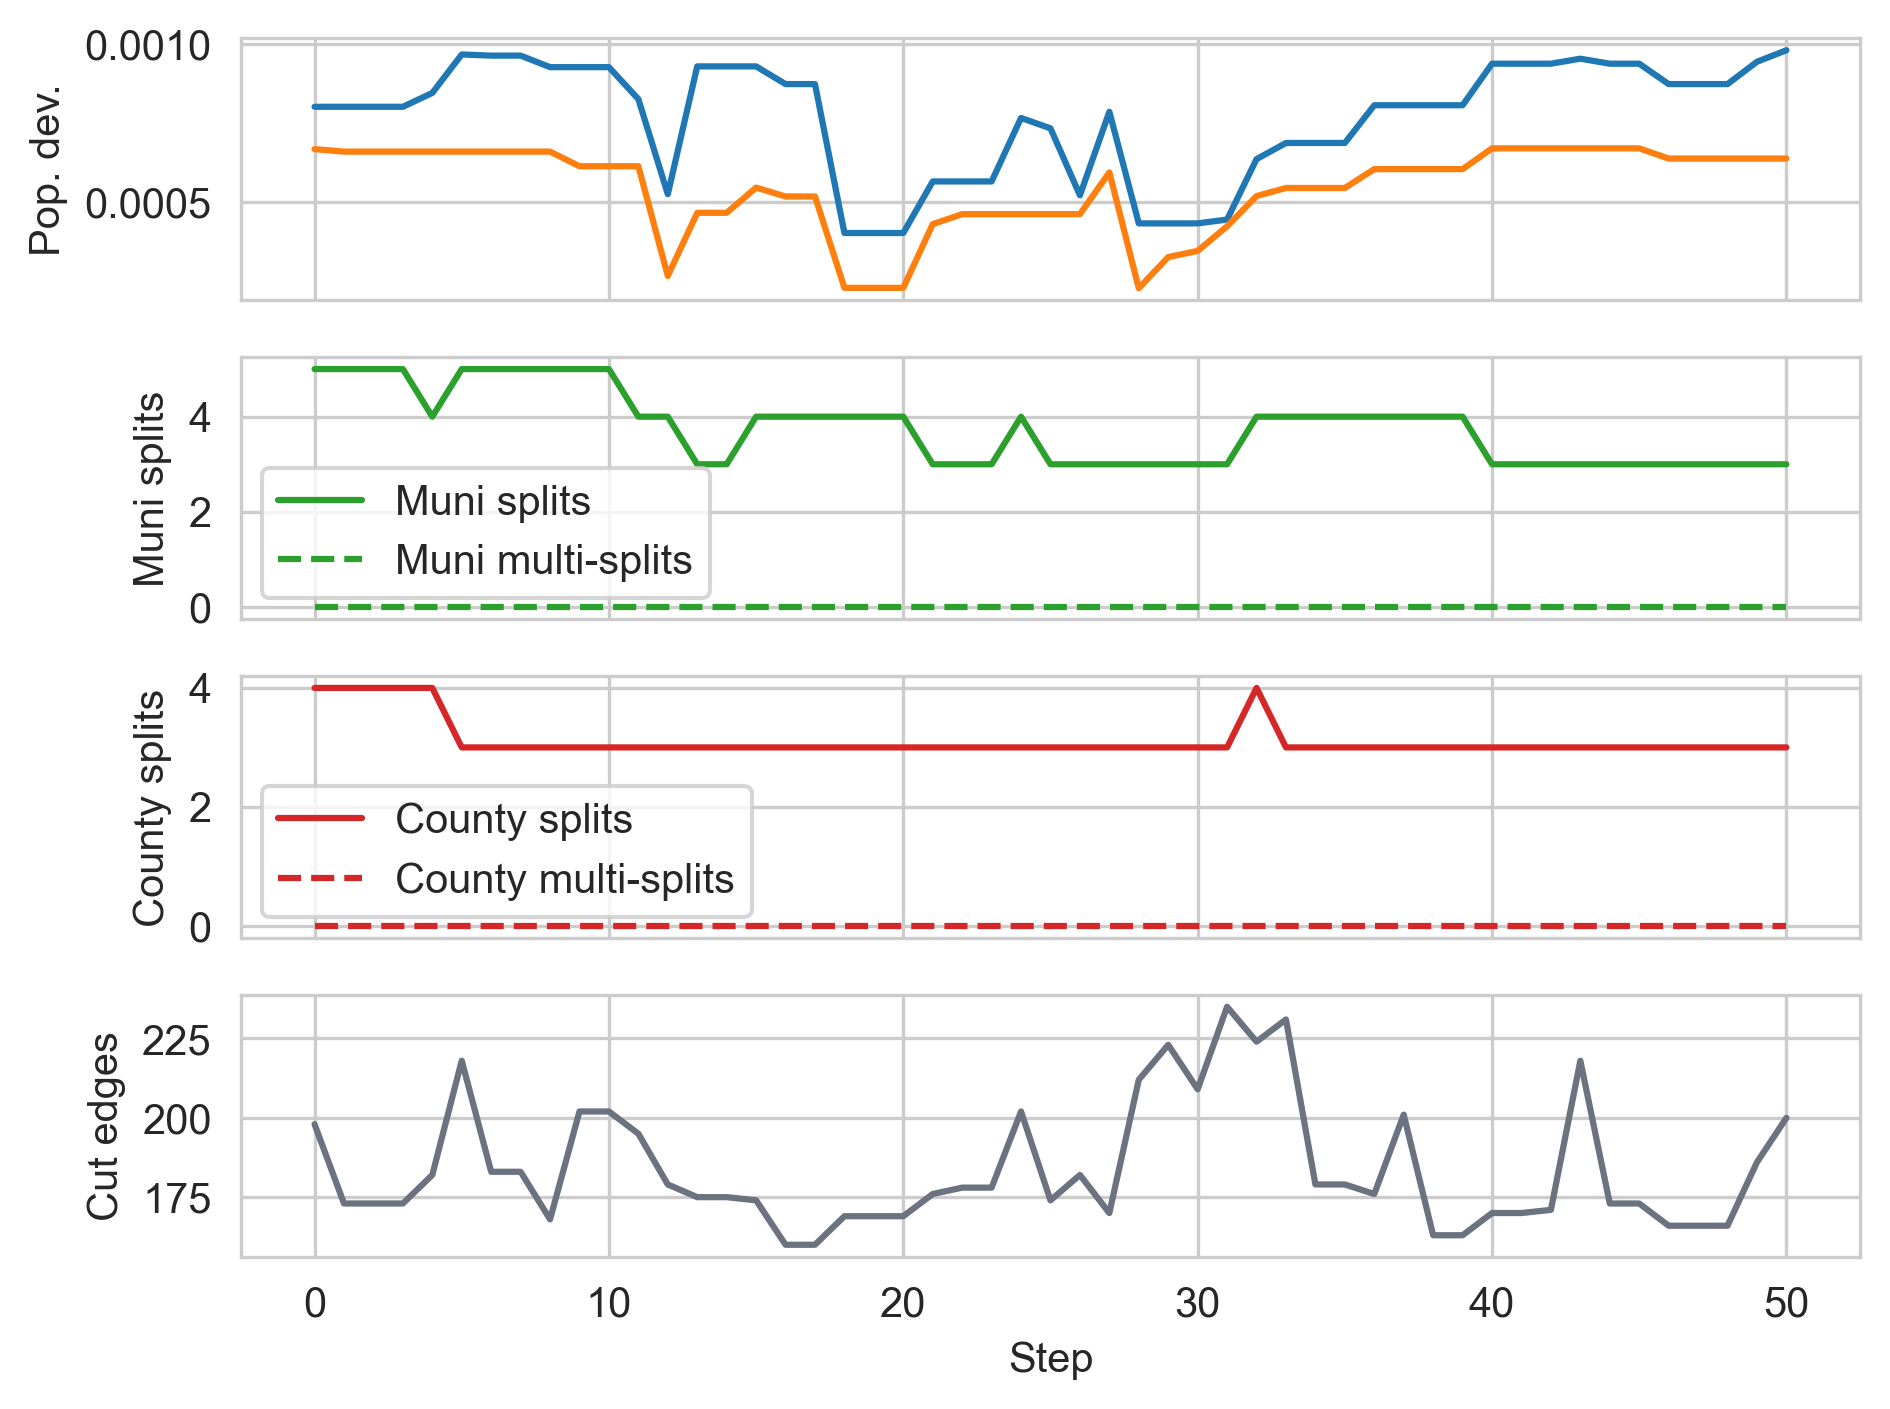

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rows = []
for r in results:
    step = r.get("step")
    split_m = r.get("split_munis_count")
    split_c = r.get("split_counties_count")
    split_m_multi = r.get("split_munis_extra_parts", 0)
    split_c_multi = r.get("split_counties_extra_parts", 0)
    cut_e = r.get("num_cut_edges")
    pop_dev = r.get("population_deviation", {})
    try:
        dev_vals = [v for v in pop_dev.values() if v is not None]
        max_dev = max(dev_vals) if dev_vals else None
        mean_dev = sum(dev_vals) / len(dev_vals) if dev_vals else None
    except Exception:
        max_dev = None
        mean_dev = None
    rows.append({
        "step": step,
        "split_munis_count": split_m,
        "split_counties_count": split_c,
        "split_munis_multi": split_m_multi,
        "split_counties_multi": split_c_multi,
        "population_max_dev": max_dev,
        "population_mean_dev": mean_dev,
        "num_cut_edges": cut_e,
    })

metrics_df = pd.DataFrame(rows).sort_values("step")

sns.set_style("whitegrid")
fig, axes = plt.subplots(4, 1, sharex=True)

axes[0].plot(metrics_df["step"], metrics_df["population_max_dev"], label="Max pop dev", color="#1f77b4")
axes[0].plot(metrics_df["step"], metrics_df["population_mean_dev"], label="Mean pop dev", color="#ff7f0e")
axes[0].set_ylabel("Pop. dev.")

# Plot municipality splits
if "split_munis_count" in metrics_df.columns:
    axes[1].plot(metrics_df["step"], metrics_df["split_munis_count"], label="Muni splits", color="#2ca02c")
if "split_munis_multi" in metrics_df.columns:
    axes[1].plot(metrics_df["step"], metrics_df["split_munis_multi"], label="Muni multi-splits", color="#2ca02c", linestyle="--")
axes[1].set_ylabel("Muni splits")
axes[1].legend()

# Plot county splits
if "split_counties_count" in metrics_df.columns:
    axes[2].plot(metrics_df["step"], metrics_df["split_counties_count"], label="County splits", color="#d62728")
if "split_counties_multi" in metrics_df.columns:
    axes[2].plot(metrics_df["step"], metrics_df["split_counties_multi"], label="County multi-splits", color="#d62728", linestyle="--")
axes[2].set_ylabel("County splits")
axes[2].legend()

axes[3].plot(metrics_df["step"], metrics_df["num_cut_edges"], label="Cut edges", color="#6b7280")
axes[3].set_ylabel("Cut edges")
axes[3].set_xlabel("Step")

fig.set_dpi(300)
plt.tight_layout()
plt.show()

In [12]:
from IPython.display import display
import ipywidgets as widgets
from PIL import Image

# Load PNGs that begin with "step_" in the config_dir directory
image_dir = str(config_dir)
image_files = sorted(
    [f for f in os.listdir(image_dir) if f.lower().endswith(".png") and f.startswith("step_")]
)

img = widgets.Image(format='png')

steps = list(range(0, ensemble_params["steps"], ensemble_params["visualize_every"]))
steps2index = {s: i for i, s in enumerate(steps)}
# Slider shows actual step numbers
stepper = widgets.BoundedIntText(value=steps[0], min=min(steps), max=max(steps), step=ensemble_params["visualize_every"], description="Step:")

frames = []
for fname in image_files:
    with open(os.path.join(image_dir, fname), "rb") as f:
        data = f.read()
    frames.append(data)

# Ensure no duplicate observers if you re-run this cell
try:
    stepper.unobserve_all()
except Exception: pass

def on_change(value):
    img.value = frames[steps2index[value]]

widgets.interactive(on_change, value=stepper)
img.value = frames[steps2index[stepper.value]]

# Create and display the widget
widget_box = widgets.VBox([stepper, img])
display(widget_box)

In [13]:
# Export YAML configuration for CLI runs inside the tag folder
import yaml

yaml_path = os.path.join(config_dir, "params.yaml")
with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.safe_dump(config, f, sort_keys=True)

print(f"Wrote YAML: {yaml_path}")

Wrote YAML: results/configurations/20251010111147/params.yaml
